# 04. Shape Constraints, Monotonicity, and Business Logic

The previous notebook focused on reading model coefficients and response surfaces correctly. This notebook takes the next step: **what should we do when a model's learned shape conflicts with domain logic?**

In many decision systems, the direction of a relationship is a statistical and governance detail. If an account has more unresolved incidents, predicted support risk should not go down when all other inputs are held fixed. If training completion improves, predicted risk should not go up simply because a flexible model found a noisy local pattern. These are not cosmetic constraints. They are part of how an organization justifies, audits, and governs its scoring systems.

We will study shape constraints through a specialist-review triage workflow. The goal is to predict which customer accounts need proactive specialist review. We will compare an unconstrained flexible model with a monotone-constrained version of the same model family, then audit whether each model respects the business logic it would need to satisfy before deployment.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Define monotonicity constraints for risk-increasing and risk-decreasing predictors.
2. Explain why monotone constraints are useful for auditability, governance, and stakeholder trust.
3. Distinguish statistical monotonicity in a prediction function from causal monotonicity in the real world.
4. Fit and compare unconstrained and monotone-constrained gradient boosting models.
5. Measure shape violations using response curves and individual conditional expectation style audits.
6. Diagnose when predictive metrics alone are insufficient for deciding whether a model is deployable.
7. Translate shape constraints into concrete business rules for a decision system.

In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:0.3f}')
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 180)
np.random.seed(2027)

FEATURES = [
    'open_tickets_30d',
    'recent_incidents_90d',
    'integration_complexity',
    'payment_delay_days',
    'usage_volatility',
    'training_completion',
    'product_adoption',
    'executive_sponsor',
    'enterprise_segment',
    'international_region',
    'pooled_support_motion',
]

CONSTRAINT_SPEC = pd.DataFrame(
    [
        {
            'feature': 'open_tickets_30d',
            'expected_direction': '+',
            'business_logic': 'More unresolved tickets should not lower predicted specialist-review risk.',
        },
        {
            'feature': 'recent_incidents_90d',
            'expected_direction': '+',
            'business_logic': 'More recent incidents should not lower predicted operational risk.',
        },
        {
            'feature': 'integration_complexity',
            'expected_direction': '+',
            'business_logic': 'More complex integrations should not be scored as safer, all else equal.',
        },
        {
            'feature': 'payment_delay_days',
            'expected_direction': '+',
            'business_logic': 'Greater commercial friction should not reduce predicted escalation risk.',
        },
        {
            'feature': 'usage_volatility',
            'expected_direction': '+',
            'business_logic': 'More unstable usage should not lower predicted intervention need.',
        },
        {
            'feature': 'training_completion',
            'expected_direction': '-',
            'business_logic': 'More completed enablement should not increase predicted risk.',
        },
        {
            'feature': 'product_adoption',
            'expected_direction': '-',
            'business_logic': 'Deeper adoption should not increase predicted risk.',
        },
        {
            'feature': 'executive_sponsor',
            'expected_direction': '-',
            'business_logic': 'A strong sponsor should not increase predicted risk by itself.',
        },
        {
            'feature': 'enterprise_segment',
            'expected_direction': '0',
            'business_logic': 'Segment is context, not a directional safety rule.',
        },
        {
            'feature': 'international_region',
            'expected_direction': '0',
            'business_logic': 'Region is context, not a directional safety rule.',
        },
        {
            'feature': 'pooled_support_motion',
            'expected_direction': '0',
            'business_logic': 'Support motion is context, not a universal monotone rule.',
        },
    ]
)

MONOTONIC_CST = (
    CONSTRAINT_SPEC['expected_direction']
    .map({'+': 1, '-': -1, '0': 0})
    .astype(int)
    .to_numpy()
)

## 1. What A Shape Constraint Means

A prediction function is **monotone increasing** in feature $x_j$ if increasing that feature while holding the other modeled features fixed cannot decrease the prediction:

$$
x_j \le x'_j,\quad x_{-j}=x'_{-j}
\quad \Longrightarrow \quad
f(x) \le f(x').
$$

It is **monotone decreasing** in feature $x_j$ if increasing that feature cannot increase the prediction:

$$
x_j \le x'_j,\quad x_{-j}=x'_{-j}
\quad \Longrightarrow \quad
f(x) \ge f(x').
$$

A constrained estimation problem can be written as

$$
\hat f
= \arg\min_{f \in \mathcal F_{\mathrm{mono}}}
\frac{1}{n}\sum_{i=1}^n L\bigl(y_i, f(x_i)\bigr),
$$

where $\mathcal F_{\mathrm{mono}}$ is the subset of candidate functions that satisfy the specified shape restrictions.

This looks like a technical modeling choice, but in decision science it is often a governance choice. A constraint says: **we are willing to sacrifice some flexibility so the deployed score cannot contradict a directional rule we are prepared to defend.**

That last phrase matters. A monotone constraint should be used only when the direction is genuinely defensible. If the rule is wrong, the constraint can hide important heterogeneity. If the rule is correct but the data are noisy, the constraint can prevent a model from turning noise into policy.

### Prediction Monotonicity Is Not Causal Monotonicity

A monotone prediction rule does **not** prove that changing a feature will causally move the outcome. For example, if the model is constrained so that predicted risk decreases with `training_completion`, that does not prove that forcing completion to rise would reduce risk for every account. It only means the scoring function has been restricted so that accounts with higher completion are not scored as riskier when all modeled features are held fixed.

That distinction is central to this portfolio's overall framing:

| Question | Modeling object | Typical use |
|---|---|---|
| Prediction monotonicity | Shape of $\hat f(x)$ | Audit, scoring logic, deployment guardrails |
| Causal monotonicity | Shape of $Y(t)$ or treatment response | Policy effect, intervention design, mechanism claims |
| Business monotonicity | Directional rule stakeholders will defend | Governance and model acceptance |

Rudin (2019) argues that high-stakes decision settings should prefer interpretable models when they can match black-box performance. Shape-constrained models are one practical way to move in that direction: they are not necessarily simple, but their response behavior can be made more aligned with domain logic. Gill, Hall, and Montgomery (2020) make a related point in a responsible ML workflow that uses constrained models and discrimination testing for human-centered or regulated applications.

## 2. Synthetic Case Study: Specialist Review Under Operational Risk

A customer success organization has a limited specialist team. Each month, it must decide which accounts need proactive specialist review. The target is `needs_specialist_review`, a binary indicator that an account will require specialist attention in the next operating cycle.

The model has access to operational burden, enablement, adoption, sponsor, and context features. Some of these have defensible directional expectations.

| Feature group | Examples | Expected shape |
|---|---|---|
| Operational burden | `open_tickets_30d`, `recent_incidents_90d`, `usage_volatility` | Risk should increase or stay flat |
| Enablement and adoption | `training_completion`, `product_adoption` | Risk should decrease or stay flat |
| Sponsor strength | `executive_sponsor` | Risk should decrease or stay flat |
| Context indicators | `enterprise_segment`, `international_region`, `pooled_support_motion` | No universal monotone rule |

The data-generating process below intentionally includes realistic noise and a small rescue-account pocket. In finite samples, flexible unconstrained models can misread those pockets as local reversals. That is exactly the kind of behavior a shape audit should catch.

In [2]:
# Section focus: 2. Synthetic Case Study: Specialist Review Under Operational Risk.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))


def make_shape_constraint_dataset(n=6500, seed=2027):
    """Construct the shape constraint dataset helper used in the 04. Shape Constraints, Monotonicity, and Business Logic workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(['growth', 'mid-market', 'enterprise'], size=n, p=[0.50, 0.32, 0.18])
    region = rng.choice(['North', 'South', 'West', 'International'], size=n, p=[0.30, 0.23, 0.29, 0.18])
    support_motion = rng.choice(['reactive', 'pooled', 'dedicated'], size=n, p=[0.50, 0.34, 0.16])

    enterprise_segment = (segment == 'enterprise').astype(int)
    international_region = (region == 'International').astype(int)
    pooled_support_motion = (support_motion == 'pooled').astype(int)

    executive_sponsor = rng.binomial(
        1,
        np.clip(0.23 + 0.22 * (segment == 'mid-market') + 0.46 * enterprise_segment - 0.09 * international_region, 0.05, 0.90),
        size=n,
    )
    open_tickets_30d = rng.poisson(
        np.clip(1.2 + 1.0 * (segment == 'mid-market') + 2.2 * enterprise_segment + 0.7 * pooled_support_motion, 0.2, None)
    )
    integration_complexity = np.clip(
        rng.normal(4.1 + 0.8 * (segment == 'mid-market') + 1.8 * enterprise_segment + 0.35 * international_region, 1.25, n),
        1.0,
        10.0,
    )
    usage_volatility = np.clip(rng.gamma(shape=2.2, scale=0.42, size=n) + 0.12 * pooled_support_motion, 0.03, 4.0)
    training_completion = np.clip(
        0.76 + 0.12 * rng.normal(size=n) - 0.08 * pooled_support_motion - 0.06 * international_region - 0.025 * enterprise_segment,
        0.03,
        0.99,
    )
    product_adoption = np.clip(
        0.62 + 0.12 * rng.normal(size=n) + 0.08 * executive_sponsor - 0.06 * usage_volatility - 0.025 * integration_complexity,
        0.03,
        0.99,
    )
    payment_delay_days = np.clip(
        rng.gamma(shape=1.6, scale=2.2, size=n) + 1.0 * international_region + 0.3 * (segment == 'growth'),
        0.0,
        35.0,
    )
    recent_incidents_90d = rng.poisson(
        np.clip(0.24 + 0.18 * open_tickets_30d + 0.11 * usage_volatility + 0.08 * (integration_complexity - 4), 0.02, None)
    )

    rescue_account = ((training_completion > 0.82) & (enterprise_segment == 1) & (open_tickets_30d >= 4)).astype(int)

    logit = (
        -5.5
        + 0.24 * open_tickets_30d
        + 0.49 * recent_incidents_90d
        + 0.22 * integration_complexity
        + 0.075 * payment_delay_days
        + 0.78 * usage_volatility
        + 1.50 * (1 - training_completion)
        + 1.05 * (1 - product_adoption)
        - 0.75 * executive_sponsor
        + 0.38 * enterprise_segment
        + 0.22 * international_region
        + 0.24 * pooled_support_motion
        + 0.25 * open_tickets_30d * (1 - training_completion)
        + 0.75 * (1 - training_completion) * (1 - product_adoption)
        + 0.14 * np.maximum(open_tickets_30d - 6, 0)
        + 0.35 * rescue_account
    )
    needs_specialist_review = rng.binomial(1, sigmoid(logit), size=n)

    return pd.DataFrame(
        {
            'segment': segment,
            'region': region,
            'support_motion': support_motion,
            'open_tickets_30d': open_tickets_30d,
            'recent_incidents_90d': recent_incidents_90d,
            'integration_complexity': integration_complexity,
            'payment_delay_days': payment_delay_days,
            'usage_volatility': usage_volatility,
            'training_completion': training_completion,
            'product_adoption': product_adoption,
            'executive_sponsor': executive_sponsor,
            'enterprise_segment': enterprise_segment,
            'international_region': international_region,
            'pooled_support_motion': pooled_support_motion,
            'rescue_account': rescue_account,
            'needs_specialist_review': needs_specialist_review,
        }
    )


def rate_by_quantile(df, feature, target, q=6):
    """Carry out the rate by quantile step used in the 04. Shape Constraints, Monotonicity, and Business Logic workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    feature : object
        Column or variable name used to select information from the input table.
    target : object
        Target column name or target values used by the supervised task.
    q : object
        Quantile level used by the risk, interval, or tail calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the rate by quantile calculation and reused by later cells.
    """
    return (
        df.groupby(pd.qcut(df[feature], q=q, duplicates='drop'), observed=False)
        .agg(mean_feature=(feature, 'mean'), target_rate=(target, 'mean'), rows=(target, 'size'))
        .reset_index(drop=True)
    )


df = make_shape_constraint_dataset()
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=2027,
    stratify=df['needs_specialist_review'],
)

summary = pd.DataFrame(
    [
        {'quantity': 'Rows', 'value': len(df)},
        {'quantity': 'Train rows', 'value': len(train_df)},
        {'quantity': 'Test rows', 'value': len(test_df)},
        {'quantity': 'Specialist-review rate', 'value': df['needs_specialist_review'].mean()},
        {'quantity': 'Average open tickets', 'value': df['open_tickets_30d'].mean()},
        {'quantity': 'Average training completion', 'value': df['training_completion'].mean()},
        {'quantity': 'Average product adoption', 'value': df['product_adoption'].mean()},
    ]
)

segment_summary = (
    df.groupby('segment', as_index=False)
    .agg(
        rows=('segment', 'size'),
        review_rate=('needs_specialist_review', 'mean'),
        mean_open_tickets=('open_tickets_30d', 'mean'),
        mean_training_completion=('training_completion', 'mean'),
        mean_product_adoption=('product_adoption', 'mean'),
    )
    .sort_values('review_rate', ascending=False)
)

smart_display(summary.round(3))
smart_display(CONSTRAINT_SPEC)
smart_display(segment_summary.round(3))
smart_display(df.head(6))

,quantity,value
0,Rows,6500.000
1,Train rows,4550.000
2,Test rows,1950.000
3,Specialist-review rate,0.262
4,Average open tickets,2.160
5,Average training completion,0.717
6,Average product adoption,0.474


,feature,expected_direction,business_logic
0,open_tickets_30d,+,More unresolved tickets should not lower predicted specialist-review risk.
1,recent_incidents_90d,+,More recent incidents should not lower predicted operational risk.
2,integration_complexity,+,"More complex integrations should not be scored as safer, all else equal."
3,payment_delay_days,+,Greater commercial friction should not reduce predicted escalation risk.
4,usage_volatility,+,More unstable usage should not lower predicted intervention need.
5,training_completion,-,More completed enablement should not increase predicted risk.
6,product_adoption,-,Deeper adoption should not increase predicted risk.
7,executive_sponsor,-,A strong sponsor should not increase predicted risk by itself.
8,enterprise_segment,0,"Segment is context, not a directional safety rule."
9,international_region,0,"Region is context, not a directional safety rule."


,segment,rows,review_rate,mean_open_tickets,mean_training_completion,mean_product_adoption
0,enterprise,1166,0.443,3.691,0.694,0.467
2,mid-market,2077,0.282,2.478,0.725,0.478
1,growth,3257,0.184,1.410,0.721,0.474


,segment,region,support_motion,open_tickets_30d,recent_incidents_90d,integration_complexity,payment_delay_days,usage_volatility,training_completion,product_adoption,executive_sponsor,enterprise_segment,international_region,pooled_support_motion,rescue_account,needs_specialist_review
0,growth,West,dedicated,1,1,3.354,0.572,1.737,0.923,0.623,0,0,0,0,0,1
1,growth,West,reactive,1,0,3.627,3.455,1.157,0.753,0.638,0,0,0,0,0,0
2,growth,International,reactive,1,0,2.798,1.377,0.588,0.734,0.585,0,0,1,0,0,0
3,growth,International,dedicated,2,1,3.721,8.295,0.704,0.675,0.447,0,0,1,0,0,0
4,growth,International,dedicated,1,0,3.514,3.597,0.813,0.805,0.523,0,0,1,0,0,0
5,mid-market,West,reactive,0,3,4.597,2.773,0.535,0.619,0.539,1,0,0,0,0,1


The constraint table is intentionally explicit. Before fitting a monotone model, we should be able to explain each constraint to a domain expert.

Two good habits follow from this:

1. Constrain only features with a defensible direction.
2. Leave context indicators unconstrained when their direction depends on process design, measurement, or omitted context.

For example, `enterprise_segment` may be associated with higher review rates, but it is not inherently a risk-increasing physical quantity. Enterprise accounts may receive different support motions, have different reporting incentives, or be more likely to be escalated for relationship reasons. Treating segment as a monotone risk law would overstate what the model knows.

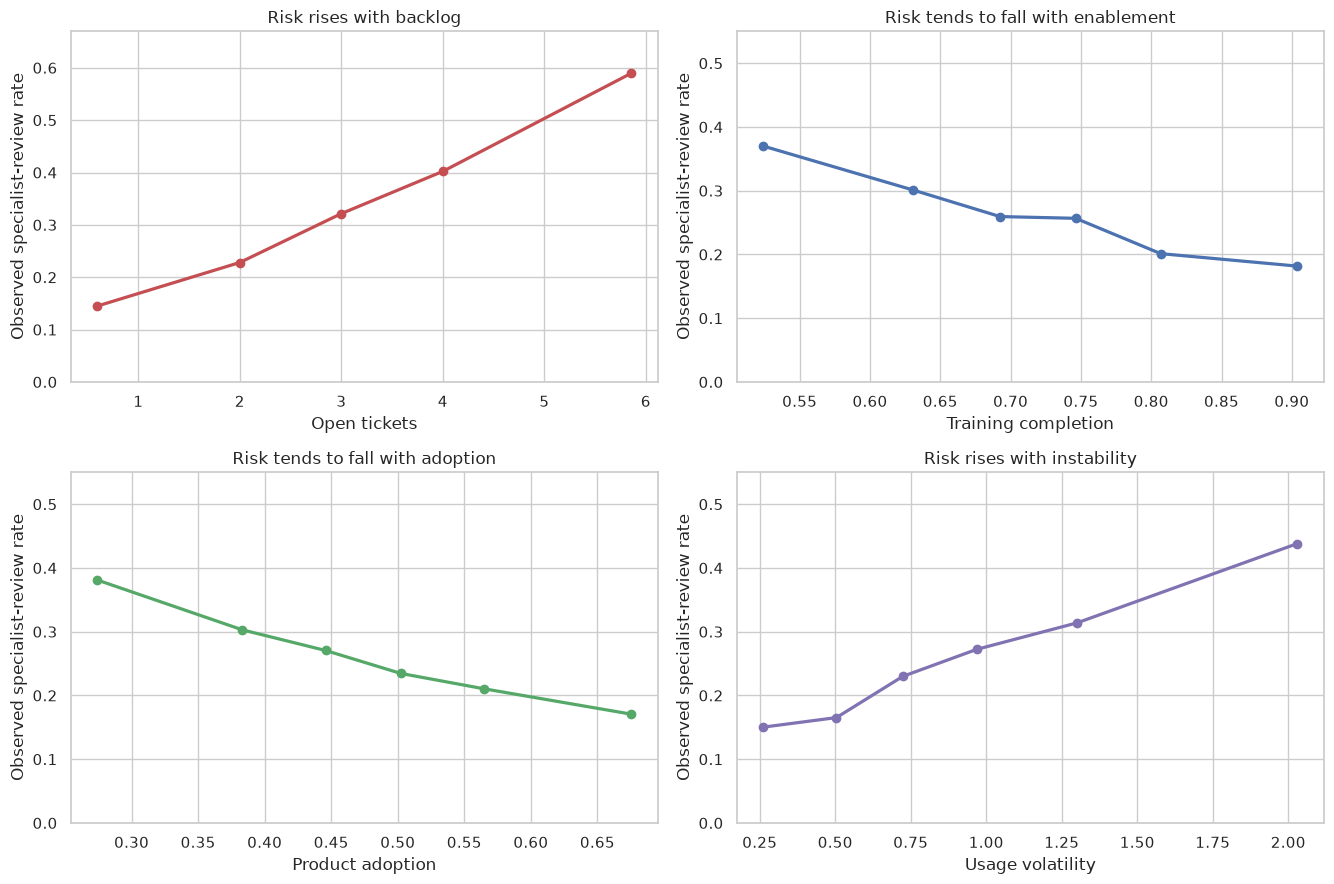

In [3]:
ticket_curve = rate_by_quantile(df, 'open_tickets_30d', 'needs_specialist_review')
training_curve = rate_by_quantile(df, 'training_completion', 'needs_specialist_review')
adoption_curve = rate_by_quantile(df, 'product_adoption', 'needs_specialist_review')
volatility_curve = rate_by_quantile(df, 'usage_volatility', 'needs_specialist_review')

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0))
curves = [
    (ticket_curve, 'open_tickets_30d', 'Open tickets', 'Risk rises with backlog', '#c44e52'),
    (training_curve, 'training_completion', 'Training completion', 'Risk tends to fall with enablement', '#4c72b0'),
    (adoption_curve, 'product_adoption', 'Product adoption', 'Risk tends to fall with adoption', '#55a868'),
    (volatility_curve, 'usage_volatility', 'Usage volatility', 'Risk rises with instability', '#8172b2'),
]

for ax, (curve, feature, xlabel, title, color) in zip(axes.ravel(), curves):
    ax.plot(curve['mean_feature'], curve['target_rate'], marker='o', linewidth=2.3, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Observed specialist-review rate')
    ax.set_ylim(0, max(0.55, curve['target_rate'].max() + 0.08))

plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Synthetic Case Study: Specialist Review Under Operational Risk, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Explanation quality matters in practice because it shapes communication, review burden, and the defensibility of the recommendation.


### Discussion of the Raw Patterns

The binned rates line up with the intended business logic: backlog, recent incidents, and volatility tend to increase review risk, while training completion and adoption tend to reduce it. But these marginal plots are not proof that every conditional model will respect those directions.

A flexible model can still learn local reversals because:

- some areas of the feature space are sparse;
- correlated predictors can make one feature stand in for another;
- high-leverage subgroups can introduce local bumps;
- sample noise can look like a real operational pattern;
- ordinary validation metrics do not penalize shape violations directly.

This is why shape auditing is a separate diagnostic from AUC, log loss, and calibration.

## 3. Fit Three Candidate Models

We fit three models to make the comparison concrete.

| Model | Role in the notebook | Interpretability issue |
|---|---|---|
| Logistic regression | Transparent baseline | Coefficients are readable, but the shape is mostly linear on the log-odds scale |
| Unconstrained gradient boosting | Flexible benchmark | Good fit, but response shapes may violate business logic |
| Monotone gradient boosting | Flexible constrained model | Same model family, but specified features must move in defensible directions |

The constrained and unconstrained boosting models use the same hyperparameters. The only intended difference is the vector of monotonicity constraints.

The monotonicity vector is aligned with the feature matrix:

$$
(1,1,1,1,1,-1,-1,-1,0,0,0),
$$

where $1$ means nondecreasing, $-1$ means nonincreasing, and $0$ means unconstrained.

,model,roc_auc,average_precision,brier_score,log_loss,precision_at_0.50,recall_at_0.50,mean_predicted_risk
0,Logistic regression,0.816,0.621,0.144,0.444,0.658,0.384,0.264
2,Monotone boosting,0.801,0.597,0.150,0.466,0.622,0.410,0.261
1,Unconstrained boosting,0.787,0.579,0.154,0.477,0.597,0.404,0.257


,model,review_fraction,score_cutoff,precision_among_reviewed,share_of_true_events_captured,review_count
0,Logistic regression,0.150000,0.505000,0.666000,0.382000,293
2,Monotone boosting,0.150000,0.544000,0.645000,0.371000,293
1,Unconstrained boosting,0.150000,0.557000,0.621000,0.357000,293


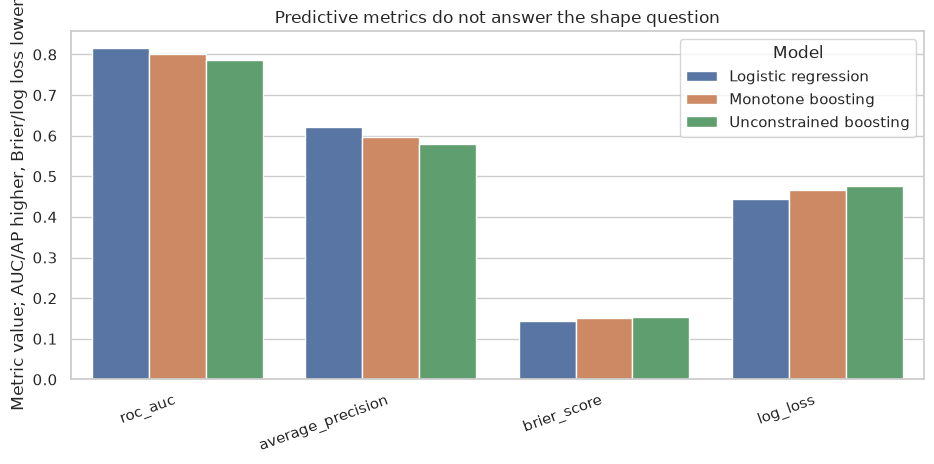

In [4]:
# Section focus: 3. Fit Three Candidate Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def classification_metrics(y_true, p_hat, threshold=0.50):
    """Carry out the classification metrics step used in the 04. Shape Constraints, Monotonicity, and Business Logic workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    p_hat : object
        Estimated probability used by the scoring, calibration, or weighting step.
    threshold : object
        Decision cutoff used to convert scores into actions or alerts.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    y_hat = (p_hat >= threshold).astype(int)
    return {
        'roc_auc': roc_auc_score(y_true, p_hat),
        'average_precision': average_precision_score(y_true, p_hat),
        'brier_score': brier_score_loss(y_true, p_hat),
        'log_loss': log_loss(y_true, p_hat),
        'precision_at_0.50': precision_score(y_true, y_hat, zero_division=0),
        'recall_at_0.50': recall_score(y_true, y_hat, zero_division=0),
        'mean_predicted_risk': float(np.mean(p_hat)),
    }


def top_fraction_policy(y_true, p_hat, fraction=0.15):
    """Carry out the top fraction policy step used in the 04. Shape Constraints, Monotonicity, and Business Logic workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    p_hat : object
        Estimated probability used by the scoring, calibration, or weighting step.
    fraction : object
        The fraction setting that controls the top fraction policy calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    cutoff = np.quantile(p_hat, 1 - fraction)
    selected = p_hat >= cutoff
    return {
        'review_fraction': selected.mean(),
        'score_cutoff': cutoff,
        'precision_among_reviewed': y_true[selected].mean(),
        'share_of_true_events_captured': y_true[selected].sum() / y_true.sum(),
        'review_count': selected.sum(),
    }


X_train = train_df[FEATURES]
y_train = train_df['needs_specialist_review']
X_test = test_df[FEATURES]
y_test = test_df['needs_specialist_review']

models = {
    'Logistic regression': Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=500, C=1.0)),
        ]
    ),
    'Unconstrained boosting': HistGradientBoostingClassifier(
        max_iter=240,
        learning_rate=0.045,
        max_leaf_nodes=31,
        min_samples_leaf=25,
        l2_regularization=0.02,
        random_state=2027,
    ),
    'Monotone boosting': HistGradientBoostingClassifier(
        max_iter=240,
        learning_rate=0.045,
        max_leaf_nodes=31,
        min_samples_leaf=25,
        l2_regularization=0.02,
        monotonic_cst=MONOTONIC_CST,
        random_state=2027,
    ),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict_proba(X_test)[:, 1]

metric_table = pd.DataFrame(
    [{'model': name, **classification_metrics(y_test, p_hat)} for name, p_hat in predictions.items()]
).sort_values('roc_auc', ascending=False)

policy_table = pd.DataFrame(
    [{'model': name, **top_fraction_policy(y_test.to_numpy(), p_hat, fraction=0.15)} for name, p_hat in predictions.items()]
).sort_values('precision_among_reviewed', ascending=False)

smart_display(metric_table.round(3))
smart_display(policy_table.round(3))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
plot_metrics = metric_table.melt(
    id_vars='model',
    value_vars=['roc_auc', 'average_precision', 'brier_score', 'log_loss'],
    var_name='metric',
    value_name='value',
)
sns.barplot(data=plot_metrics, x='metric', y='value', hue='model', ax=ax)
ax.set_title('Predictive metrics do not answer the shape question')
ax.set_xlabel('')
ax.set_ylabel('Metric value; AUC/AP higher, Brier/log loss lower')
ax.legend(title='Model', loc='upper right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For Fit Three Candidate Models, look at whether the explanation is stable, plausible, and useful for stakeholder review. When reasonable explanation settings lead to different conclusions, the model story should stay provisional.


### Discussion of Predictive Performance

The transparent logistic baseline is strong in this simulated workflow. That is useful: it reinforces the course principle that transparent baselines deserve serious comparison. In the metric plot, AUC and average precision are better when higher, while Brier score and log loss are better when lower.

The two boosting models answer a more specific question. The monotone-constrained model keeps the same basic flexibility as boosting while restricting the directions of selected response functions. If the constrained model had much worse AUC, average precision, or log loss, we would need to decide whether the governance benefit is worth the accuracy cost. In this run, the constrained model remains competitive and the top-capacity policy table remains operationally usable.

But the main lesson is that none of these tables tells us whether the model respects the stated directional rules. Predictive metrics evaluate ranking, probability quality, and threshold behavior. They do not directly evaluate whether a score behaves sensibly when one operational input is varied and all others are held fixed.

## 4. Auditing Shape Violations

A response-curve audit asks a simple question:

> If I hold account profiles fixed and vary one feature over a grid, does the prediction ever move in the forbidden direction?

For a risk-increasing feature, forbidden movement means a negative step in the predicted risk curve:

$$
\Delta_k = \hat p(x_j^{(k+1)}) - \hat p(x_j^{(k)}) < -\varepsilon.
$$

For a risk-decreasing feature, forbidden movement means a positive step:

$$
\Delta_k = \hat p(x_j^{(k+1)}) - \hat p(x_j^{(k)}) > \varepsilon.
$$

The tolerance $\varepsilon$ avoids treating tiny numerical jitter as a meaningful violation. This is an ICE-style audit because we repeat the check over many baseline profiles rather than looking only at one average curve.

,feature,expected_direction,model,profile_violation_rate,step_violation_share,max_single_step_violation,mean_endpoint_shift
0,open_tickets_30d,increasing,Unconstrained boosting,0.873,0.077,0.148,0.314
1,open_tickets_30d,increasing,Monotone boosting,0.000,0.000,0.000,0.354
2,recent_incidents_90d,increasing,Unconstrained boosting,0.278,0.014,0.185,0.348
3,recent_incidents_90d,increasing,Monotone boosting,0.000,0.000,0.000,0.404
4,payment_delay_days,increasing,Unconstrained boosting,1.000,0.266,0.248,0.002
5,payment_delay_days,increasing,Monotone boosting,0.000,0.000,0.000,0.145
6,usage_volatility,increasing,Unconstrained boosting,1.000,0.284,0.271,0.384
7,usage_volatility,increasing,Monotone boosting,0.000,0.000,0.000,0.468
8,training_completion,decreasing,Unconstrained boosting,1.000,0.228,0.301,-0.170
9,training_completion,decreasing,Monotone boosting,0.000,0.000,0.000,-0.265


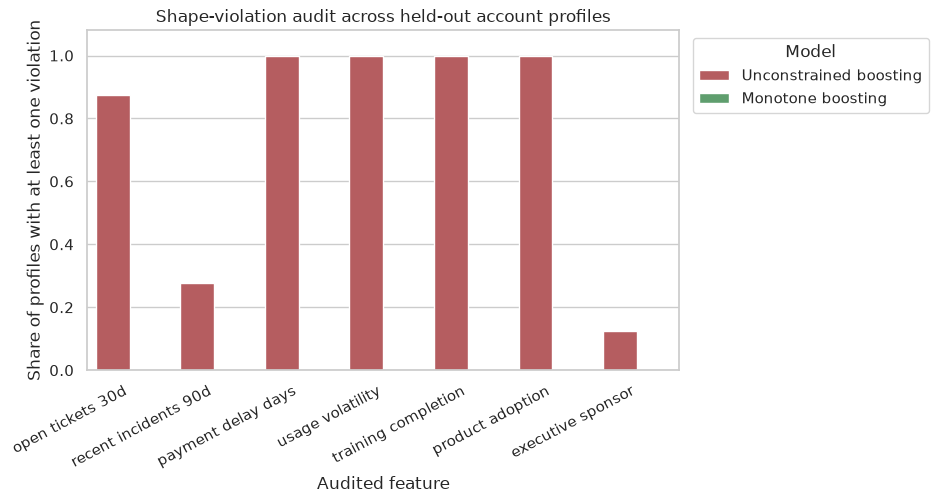

In [5]:
# Section focus: 4. Auditing Shape Violations.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

AUDIT_FEATURES = {
    'open_tickets_30d': {'direction': 1, 'grid': np.linspace(0, 12, 25), 'label': 'Open tickets'},
    'recent_incidents_90d': {'direction': 1, 'grid': np.linspace(0, 8, 25), 'label': 'Recent incidents'},
    'payment_delay_days': {'direction': 1, 'grid': np.linspace(0, 24, 25), 'label': 'Payment delay days'},
    'usage_volatility': {'direction': 1, 'grid': np.linspace(0.05, 3.0, 25), 'label': 'Usage volatility'},
    'training_completion': {'direction': -1, 'grid': np.linspace(0.05, 0.99, 25), 'label': 'Training completion'},
    'product_adoption': {'direction': -1, 'grid': np.linspace(0.05, 0.99, 25), 'label': 'Product adoption'},
    'executive_sponsor': {'direction': -1, 'grid': np.array([0, 1]), 'label': 'Executive sponsor'},
}


def predict_for_grid(model, baseline_frame, feature, grid):
    """Carry out the predict for grid step used in the 04. Shape Constraints, Monotonicity, and Business Logic workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    baseline_frame : object
        Tabular data object used as the input or output of this workflow step.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    
    Returns
    -------
    object
        Intermediate result produced by the predict for grid calculation and reused by later cells.
    """
    predictions_by_value = []
    for value in grid:
        modified = baseline_frame.copy()
        modified[feature] = value
        predictions_by_value.append(model.predict_proba(modified[FEATURES])[:, 1])
    return np.vstack(predictions_by_value).T


def monotonic_violation_summary(model, baseline_frame, feature, grid, direction, tolerance=1e-5):
    """Carry out the monotonic violation summary step used in the 04. Shape Constraints, Monotonicity, and Business Logic workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    baseline_frame : object
        Tabular data object used as the input or output of this workflow step.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    direction : object
        The direction setting that controls the monotonic violation summary calculation in this notebook.
    tolerance : object
        The tolerance setting that controls the monotonic violation summary calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    pred_matrix = predict_for_grid(model, baseline_frame, feature, grid)
    diffs = np.diff(pred_matrix, axis=1)
    violation_mask = diffs < -tolerance if direction == 1 else diffs > tolerance
    violation_sizes = np.where(violation_mask, np.abs(diffs), 0.0)
    total_shift = pred_matrix[:, -1] - pred_matrix[:, 0]

    return {
        'profile_violation_rate': violation_mask.any(axis=1).mean(),
        'step_violation_share': violation_mask.mean(),
        'max_single_step_violation': violation_sizes.max(),
        'mean_endpoint_shift': total_shift.mean(),
    }


def average_response_curve(model, baseline_frame, feature, grid):
    """Carry out the average response curve step used in the 04. Shape Constraints, Monotonicity, and Business Logic workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    baseline_frame : object
        Tabular data object used as the input or output of this workflow step.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    pred_matrix = predict_for_grid(model, baseline_frame, feature, grid)
    return pd.DataFrame(
        {
            'feature_value': grid,
            'mean_predicted_risk': pred_matrix.mean(axis=0),
            'p10': np.quantile(pred_matrix, 0.10, axis=0),
            'p90': np.quantile(pred_matrix, 0.90, axis=0),
        }
    )


audit_profiles = X_test.sample(450, random_state=2027).reset_index(drop=True)

audit_rows = []
for feature, spec in AUDIT_FEATURES.items():
    for model_name in ['Unconstrained boosting', 'Monotone boosting']:
        audit_rows.append(
            {
                'feature': feature,
                'expected_direction': 'increasing' if spec['direction'] == 1 else 'decreasing',
                'model': model_name,
                **monotonic_violation_summary(
                    models[model_name],
                    audit_profiles,
                    feature,
                    spec['grid'],
                    spec['direction'],
                ),
            }
        )

audit_table = pd.DataFrame(audit_rows)
smart_display(audit_table.round(4))

fig, ax = plt.subplots(figsize=(11.2, 5.2))
plot_audit = audit_table.copy()
plot_audit['feature_label'] = plot_audit['feature'].str.replace('_', ' ')
sns.barplot(
    data=plot_audit,
    x='feature_label',
    y='profile_violation_rate',
    hue='model',
    ax=ax,
    palette=['#c44e52', '#55a868'],
)
ax.set_title('Shape-violation audit across held-out account profiles')
ax.set_xlabel('Audited feature')
ax.set_ylabel('Share of profiles with at least one violation')
ax.set_ylim(0, 1.08)
ax.legend(title='Model', loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.xticks(rotation=28, ha='right')
plt.tight_layout(rect=[0, 0, 0.84, 1])
plt.show()

This result is an interpretation diagnostic. For Auditing Shape Violations, look at whether the explanation is stable, plausible, and useful for stakeholder review. A story that moves across samples or baselines needs a careful qualification in the final report.


### Discussion of the Shape Audit

The contrast is the core of the notebook.

The unconstrained boosting model can perform well on standard metrics while still producing response curves that locally move in the wrong direction. That is not a programming error. It is a natural consequence of fitting flexible functions to finite, noisy, correlated data.

The monotone boosting model has a different contract: for constrained features, it is not allowed to produce those local reversals. This does not make the model causally correct, and it does not make every coefficient-style interpretation available. It does make the score more defensible as a decision-support object.

This is why the audit table should be read alongside the predictive metric table. In high-stakes or resource-allocation settings, a model may fail governance even when it passes predictive validation.

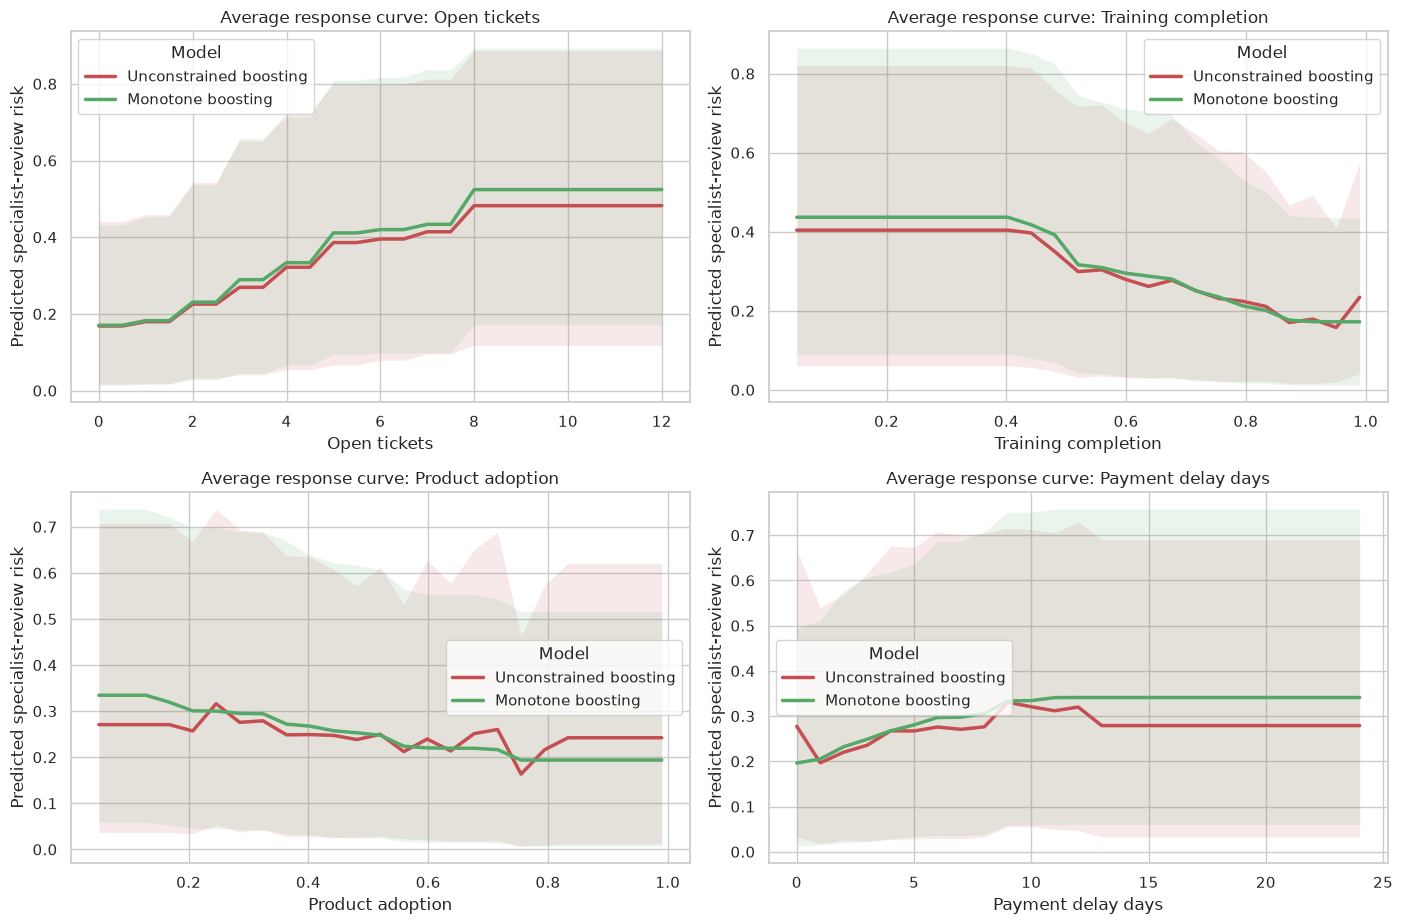

In [6]:
response_features = ['open_tickets_30d', 'training_completion', 'product_adoption', 'payment_delay_days']
fig, axes = plt.subplots(2, 2, figsize=(14.2, 9.4))

for ax, feature in zip(axes.ravel(), response_features):
    spec = AUDIT_FEATURES[feature]
    grid = spec['grid']
    for model_name, color in [('Unconstrained boosting', '#c44e52'), ('Monotone boosting', '#55a868')]:
        curve = average_response_curve(models[model_name], audit_profiles, feature, grid)
        ax.plot(curve['feature_value'], curve['mean_predicted_risk'], linewidth=2.5, label=model_name, color=color)
        ax.fill_between(
            curve['feature_value'],
            curve['p10'],
            curve['p90'],
            color=color,
            alpha=0.12,
            linewidth=0,
        )
    ax.set_title(f"Average response curve: {spec['label']}")
    ax.set_xlabel(spec['label'])
    ax.set_ylabel('Predicted specialist-review risk')
    ax.legend(title='Model', loc='best')

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For Discussion of the Shape Audit, look at whether the explanation is stable, plausible, and useful for stakeholder review. Even a fragile story can help, provided the analyst states where it changes.


### Reading the Response Curves

Each panel holds a sample of accounts fixed and varies only one feature. The solid line is the average predicted risk, while the shaded band shows the middle 80 percent of profile-level predicted risks at each grid value.

The unconstrained model may show wiggles. Some wiggles are harmless if the model is only used for offline ranking and no one will inspect the directional logic. But for an auditable decision system, they are a problem because a stakeholder can ask reasonable questions such as:

- Why did predicted risk fall when open tickets increased?
- Why did predicted risk rise when training completion improved?
- Why did commercial delay reduce the score for this account?

A monotone constraint does not answer every modeling question, but it prevents a class of answers that the organization already knows it does not want to defend.

## 5. Individual Curves: The Average Can Hide Violations

Average response curves are useful, but they can hide profile-level reversals. A model may have a sensible average curve while still violating monotonicity for many individual profiles.

The next plot draws a small set of individual response curves for `training_completion`. The business rule is decreasing: predicted risk should not rise as completion improves, all else equal.

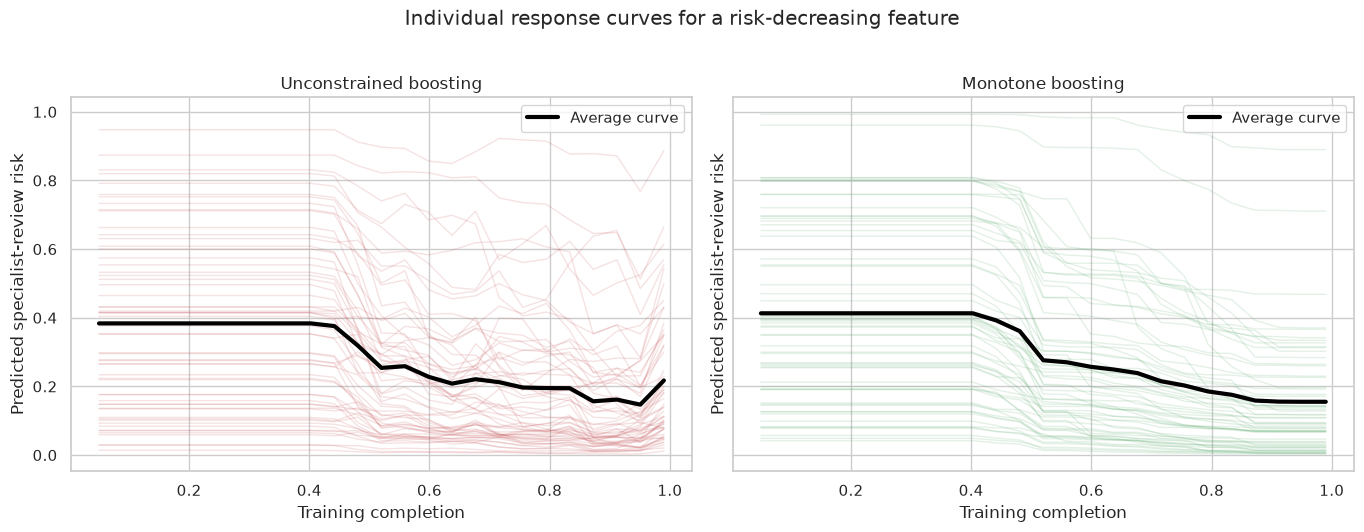

In [7]:
ice_profiles = X_test.sample(60, random_state=17).reset_index(drop=True)
feature = 'training_completion'
grid = AUDIT_FEATURES[feature]['grid']

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.2), sharey=True)
for ax, model_name, color in zip(axes, ['Unconstrained boosting', 'Monotone boosting'], ['#c44e52', '#55a868']):
    pred_matrix = predict_for_grid(models[model_name], ice_profiles, feature, grid)
    for row in pred_matrix:
        ax.plot(grid, row, color=color, alpha=0.16, linewidth=1.0)
    ax.plot(grid, pred_matrix.mean(axis=0), color='black', linewidth=3.0, label='Average curve')
    ax.set_title(model_name)
    ax.set_xlabel('Training completion')
    ax.set_ylabel('Predicted specialist-review risk')
    ax.legend(loc='upper right')

plt.suptitle('Individual response curves for a risk-decreasing feature', y=1.02)
plt.tight_layout()
plt.show()

This is often the most persuasive plot for nontechnical stakeholders. The constrained model makes the rule visible: every individual curve slopes downward or stays flat as training completion rises. The unconstrained model can produce local upward segments because it is free to fit idiosyncratic sample patterns.

The constrained model is not always better. In this setting, it is better aligned with the stated deployment contract. If a domain expert says, "I do not believe risk should always decrease with training completion because some rushed training marks accounts in trouble," then we should not impose this constraint. We would instead engineer a better variable that separates normal completion from rescue completion.

## 6. Response Surfaces Under Constraints

Monotonicity in one feature does not remove interactions. The model can still learn that the effect of training completion is larger for high-backlog accounts than for low-backlog accounts.

For a constrained function, we can require that risk is nondecreasing in ticket backlog and nonincreasing in training completion while still allowing the surface to bend:

$$
\frac{\partial \hat p}{\partial \text{tickets}} \ge 0,
\qquad
\frac{\partial \hat p}{\partial \text{training}} \le 0,
$$

where the derivative notation is conceptual. Tree-based models are piecewise constant, so the practical audit uses finite differences rather than literal derivatives.

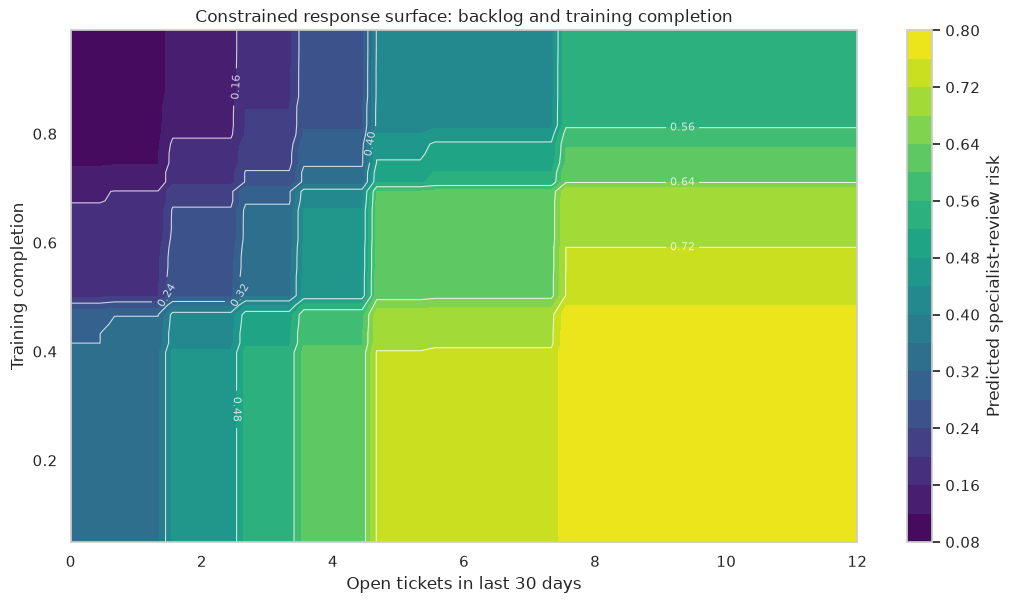

In [8]:
profile = X_test.median(numeric_only=True).to_frame().T
profile = pd.concat([profile] * 1, ignore_index=True)

ticket_grid = np.linspace(0, 12, 55)
training_grid = np.linspace(0.05, 0.99, 55)
surface = np.zeros((len(training_grid), len(ticket_grid)))

for i, training_value in enumerate(training_grid):
    batch = pd.concat([profile] * len(ticket_grid), ignore_index=True)
    batch['open_tickets_30d'] = ticket_grid
    batch['training_completion'] = training_value
    surface[i, :] = models['Monotone boosting'].predict_proba(batch[FEATURES])[:, 1]

fig, ax = plt.subplots(figsize=(10.8, 6.2))
contour = ax.contourf(ticket_grid, training_grid, surface, levels=18, cmap='viridis')
line = ax.contour(ticket_grid, training_grid, surface, levels=8, colors='white', linewidths=0.8, alpha=0.75)
ax.clabel(line, inline=True, fontsize=8, fmt='%0.2f')
colorbar = fig.colorbar(contour, ax=ax)
colorbar.set_label('Predicted specialist-review risk')
ax.set_title('Constrained response surface: backlog and training completion')
ax.set_xlabel('Open tickets in last 30 days')
ax.set_ylabel('Training completion')
plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Response Surfaces Under Constraints, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. A weak explanation creates extra review work and makes the recommendation harder to defend.


### Discussion of the Surface

The response surface shows the value of shape constraints over simple linearity. The surface can still be nonlinear: the risk difference between two and four tickets need not equal the risk difference between eight and ten tickets. The model can also learn interaction-like behavior: training completion may matter more when operational burden is high.

What the constraint prevents is directional contradiction. Moving right on the plot should not make risk lower. Moving upward on the plot should not make risk higher. That is a more modest and often more realistic requirement than forcing the entire model to be linear.

## 7. When Constraints Help, Hurt, Or Mislead

Shape constraints are most useful when three conditions hold:

| Condition | Why it matters | Example |
|---|---|---|
| Directional knowledge is defensible | The constraint becomes part of model governance | More unresolved incidents should not reduce service-risk score |
| Measurement is aligned with the rule | The feature must mean what the rule assumes it means | Training completion must distinguish normal training from emergency remediation |
| The model is used in an auditable workflow | Stakeholders will inspect and challenge score behavior | Specialist-review prioritization, credit risk, safety triage, clinical risk scoring |

They can hurt when the direction is wrong or too coarse. Suppose `payment_delay_days` mixes ordinary billing delays with approved enterprise procurement cycles. A monotone increasing constraint may unfairly score accounts as risky because the feature is not measuring the intended concept cleanly.

They can also mislead when teams confuse constrained prediction with intervention evidence. A monotone model can make a score more stable and defensible, but it does not answer whether changing the feature would causally change the outcome.

In [9]:
# Section focus: 7. When Constraints Help, Hurt, Or Mislead.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

constraint_decision_table = pd.DataFrame(
    [
        {
            'candidate_constraint': 'Risk should rise with open tickets.',
            'deployable_if': 'Open tickets are measured consistently and represent unresolved burden.',
            'watch_out_for': 'Ticket-count incentives could encourage closing tickets without solving problems.',
        },
        {
            'candidate_constraint': 'Risk should fall with training completion.',
            'deployable_if': 'Completion reflects meaningful enablement rather than emergency remediation.',
            'watch_out_for': 'High completion may identify rescue accounts unless rescue status is modeled separately.',
        },
        {
            'candidate_constraint': 'Risk should fall with product adoption.',
            'deployable_if': 'Adoption measures healthy usage, not frantic usage before failure.',
            'watch_out_for': 'Raw activity can rise during instability; use adoption quality, not only volume.',
        },
        {
            'candidate_constraint': 'Risk should fall with executive sponsorship.',
            'deployable_if': 'Sponsor indicator is current, verified, and not merely a proxy for account size.',
            'watch_out_for': 'Sponsor flags can be stale or strategically updated after an account becomes risky.',
        },
        {
            'candidate_constraint': 'Risk should rise with payment delay.',
            'deployable_if': 'Delay reflects commercial stress rather than normal procurement process.',
            'watch_out_for': 'The same feature may mean different things across regions or segments.',
        },
    ]
)
smart_display(constraint_decision_table)

,candidate_constraint,deployable_if,watch_out_for
0,Risk should rise with open tickets.,Open tickets are measured consistently and represent unresolved burden.,Ticket-count incentives could encourage closing tickets without solving problems.
1,Risk should fall with training completion.,Completion reflects meaningful enablement rather than emergency remediation.,High completion may identify rescue accounts unless rescue status is modeled separately.
2,Risk should fall with product adoption.,"Adoption measures healthy usage, not frantic usage before failure.","Raw activity can rise during instability; use adoption quality, not only volume."
3,Risk should fall with executive sponsorship.,"Sponsor indicator is current, verified, and not merely a proxy for account size.",Sponsor flags can be stale or strategically updated after an account becomes risky.
4,Risk should rise with payment delay.,Delay reflects commercial stress rather than normal procurement process.,The same feature may mean different things across regions or segments.


This result is an interpretation diagnostic. For When Constraints Help, Hurt, Or Mislead, look at whether the explanation is stable, plausible, and useful for stakeholder review. Different conclusions under reasonable settings should keep the explanation in review.


## 8. Practical Workflow For Shape-Constrained Decision Models

A disciplined workflow is:

1. **Start with the decision.** Identify the action the score will support.
2. **List directional claims.** Separate risk-increasing, risk-decreasing, and context-only variables.
3. **Challenge each claim.** Ask whether the direction is a causal claim, a prediction-shape claim, or a business-governance rule.
4. **Fit transparent and flexible baselines.** Do not assume constraints are needed before checking simpler models.
5. **Fit constrained alternatives.** Compare predictive metrics and operational policy metrics.
6. **Run shape audits.** Check profile-level violations alongside average response curves.
7. **Document exceptions.** If a variable has a plausible reversal, engineer a better feature or leave it unconstrained.
8. **Monitor after deployment.** Constraints do not prevent data drift, target drift, or measurement gaming.

This workflow is close in spirit to responsible ML frameworks that combine interpretable models, discrimination testing, and deployment diagnostics (Gill et al., 2020). It also matches the broader argument that high-stakes settings should not accept black-box complexity when interpretable or structurally constrained models can provide comparable performance (Rudin, 2019).

## 9. Key Takeaways

- A monotone constraint restricts the shape of a prediction function, not the causal structure of the world.
- Directional constraints are useful when the organization can defend the rule under audit.
- Predictive metrics alone do not reveal whether a model violates business logic.
- Response curves and ICE-style audits make shape behavior visible.
- The constrained model can remain flexible through nonlinearities and interactions while forbidding directional contradictions.
- The most dangerous use of shape constraints is to impose a neat story on a poorly measured feature.
- The best use of shape constraints is to make a decision-support score more stable, auditable, and aligned with domain knowledge.

## References

- Cano, J.-R., Gutiérrez, P. A., Krawczyk, B., Woźniak, M., & García, S. (2019). *Monotonic classification: An overview on algorithms, performance measures and data sets*. *Neurocomputing, 341*, 168-182. [https://doi.org/10.1016/j.neucom.2019.02.024](https://doi.org/10.1016/j.neucom.2019.02.024)
- Caruana, R., Lou, Y., Gehrke, J., Koch, P., Sturm, M., & Elhadad, N. (2015). *Intelligible Models for HealthCare*. Proceedings of the 21st ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 1721-1730. [https://doi.org/10.1145/2783258.2788613](https://doi.org/10.1145/2783258.2788613)
- Gill, N., Hall, P., Montgomery, K., & Schmidt, N. (2020). *A Responsible Machine Learning Workflow with Focus on Interpretable Models, Post-hoc Explanation, and Discrimination Testing*. *Information, 11*(3), 137. [https://doi.org/10.3390/info11030137](https://doi.org/10.3390/info11030137)
- Nori, H., Jenkins, S., Koch, P., & Caruana, R. (2019). *InterpretML: A Unified Framework for Machine Learning Interpretability*. arXiv. [https://doi.org/10.48550/arXiv.1909.09223](https://doi.org/10.48550/arXiv.1909.09223)
- Rudin, C. (2019). *Stop explaining black box machine learning models for high stakes decisions and use interpretable models instead*. *Nature Machine Intelligence, 1*(5), 206-215. [https://doi.org/10.1038/s42256-019-0048-x](https://doi.org/10.1038/s42256-019-0048-x)
